<p align="center">
    <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-SinFondo.png"
         width="500"/>
</p>

<h2 align="left"><i>ITESO, Universidad Jesuita de Guadalajara</i></h2>
<h2 align="left"><i>Alumno(a): Luis Carlos Alvarado</i></h2>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

import warnings
from sklearn.exceptions import FitFailedWarning
warnings.simplefilter('ignore', FitFailedWarning)
warnings.simplefilter('ignore', UserWarning)

from funciones import dummify, dqr, drop_outliers_iqr, metrics, lr_coef_importance, confusion_matrix_mult, confusion_matrix_binary, build_strategy_to_majority, smote_fit_resample, svc_hiper_search_binary, svc_hiper_search_mult, compare_models_multi_data, train_cluster_then_classify, plot_class_histograms, plot_logreg_coefs_panel_safe, _roc_binary, _roc_multiclass

In [2]:
data = pd.read_excel('BD_factores_de_riesgo.xlsx')
data

,Edad,Sexo,Peso al Nacer,Horas de sueño,Duerme menos de 8 horas,Familiares con obesidad,Codificación Familiares con obesidad,Familiares con DM,Codificación Familiares con DM,Ganancia del peso del niño de más de > 10 kg en el primer año,...,Sistólica en mmHg,Diastólica en mmHg,HTA Niñas,HTA niños,HTA adolescentes,HTA adultos,Clasificación HTA,Casual Glucemia mg/dl,Alteración,Diabetes
0,6,1,2,8.0,0,1,1,1,1,0,...,100,70,0.0,NaN,NaN,NaN,0,112,1,0
1,18,1,2,7.0,1,1,2,1,3,0,...,114,70,NaN,NaN,NaN,0.0,0,100,1,0
2,19,2,2,8.0,0,0,0,1,3,0,...,124,80,NaN,NaN,NaN,2.0,2,95,0,0
3,9,2,1,8.0,0,1,7,1,3,0,...,100,60,NaN,0.0,NaN,NaN,0,68,0,0
4,6,1,2,8.0,0,0,0,1,1,1,...,90,60,0.0,NaN,NaN,NaN,0,127,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3564,15,2,2,6.0,1,1,6,0,0,1,...,110,50,NaN,NaN,0.0,NaN,0,104,1,0
3565,10,2,1,7.0,1,0,0,1,3,0,...,100,70,NaN,0.0,NaN,NaN,0,120,1,0
3566,10,2,2,7.0,1,1,2,1,5,0,...,110,70,NaN,0.0,NaN,NaN,0,120,1,0
3567,11,2,3,8.0,0,0,0,1,1,1,...,110,70,NaN,0.0,NaN,NaN,0,98,0,0


In [3]:
data.columns

Index(['Edad', 'Sexo', 'Peso al Nacer ', 'Horas de sueño',
       'Duerme menos de 8 horas', 'Familiares con obesidad',
       'Codificación Familiares con obesidad', 'Familiares con DM',
       'Codificación Familiares con DM',
       'Ganancia del peso del niño de más de > 10 kg en el primer año',
       'Lactancia Materna',
       'Ganancia de peso materno en embarazo mayor a 10 kg',
       'Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)',
       'Ingesta diaria de alimentos de alto contenido calórico Más de 2 veces por semana',
       'No. De piezas al día',
       'Ingesta diaria de bebidas azúcaradas Más de 2 veces por semana',
       'Mililitros al día', 'AF17 años', 'AF 18 años', 'AF cumple',
       'Tipo actividad fisica realizada', 'Tipo de Deporte (si corresponde)',
       'Minutos que realiza actividad física al día',
       'Horas que pasa sentado al día', 'Peso en kg', 'Estatura en cm',
       'Estatura en mts', 'IMC        Kg/mts2', 'Bajo p

In [4]:
data['Circunferencia de cintura Con riesgo p >75'] = data['Circunferencia de cintura Con riesgo p >75'].replace({2:0, 1:1})
data = data[data['IMC OMS Clasificación'] != 4]
data = data[data['AF17 años'] != 2]

In [5]:
data.shape

(3293, 46)

In [6]:
X = data.drop(['IMC OMS Clasificación','Alteración','Clasificación HTA','Bajo peso < -2 DE','Normal ≥ -2 a ≤ +1 DE', 'Sobrepeso >+1 a ≤+2 DE', 'Obesidad >+2 DE','Estatura en cm', 'AF 18 años', 'HTA Niñas', 'HTA niños', 'HTA adolescentes', 'HTA adultos', 'Mililitros al día', 'Resultado Porcentaje de Grasa Corporal', 'Diabetes'], axis = 1)
Y1 = data["IMC OMS Clasificación"]
Y2 = data["Alteración"]
Y3 = data["Clasificación HTA"]

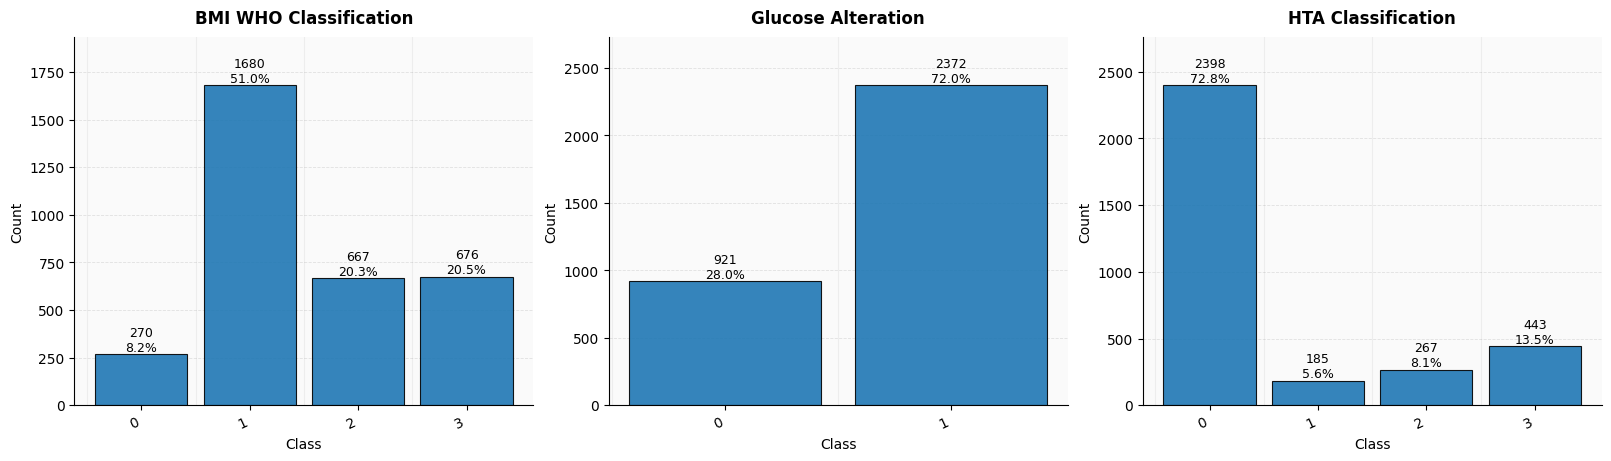

In [7]:
plot_class_histograms(Y1, Y2, Y3)

In [8]:
cols_obj = X.select_dtypes(include='object').columns.tolist()
X[cols_obj] = X[cols_obj].apply(pd.to_numeric, errors='coerce').astype('float64')

In [9]:
X = dummify(X, cols=['Sexo', 'Codificación Familiares con obesidad', 'Codificación Familiares con DM','Tipo actividad fisica realizada', 'Tipo de Deporte (si corresponde)'], drop_first=True)

In [10]:
X.dtypes

Edad                                                                                  int64
Peso al Nacer                                                                         int64
Horas de sueño                                                                      float64
Duerme menos de 8 horas                                                               int64
Familiares con obesidad                                                               int64
Familiares con DM                                                                     int64
Ganancia del peso del niño de más de > 10 kg en el primer año                       float64
Lactancia Materna                                                                   float64
Ganancia de peso materno en embarazo mayor a 10 kg                                  float64
Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)       float64
Ingesta diaria de alimentos de alto contenido calórico Más de 2 veces por semana

In [11]:
X.describe()

,Edad,Peso al Nacer,Horas de sueño,Duerme menos de 8 horas,Familiares con obesidad,Familiares con DM,Ganancia del peso del niño de más de > 10 kg en el primer año,Lactancia Materna,Ganancia de peso materno en embarazo mayor a 10 kg,"Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)",...,Codificación Familiares con DM__6,Codificación Familiares con DM__7,Tipo actividad fisica realizada__2.0,Tipo actividad fisica realizada__3.0,Tipo de Deporte (si corresponde)__2.0,Tipo de Deporte (si corresponde)__3.0,Tipo de Deporte (si corresponde)__4.0,Tipo de Deporte (si corresponde)__5.0,Tipo de Deporte (si corresponde)__6.0,Tipo de Deporte (si corresponde)__7.0
count,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3288.000000,3292.000000,3281.000000,3286.000000,...,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000,3293.000000
mean,10.958397,2.058913,8.303097,0.191315,0.422411,0.488309,0.212895,0.356622,0.345017,0.654900,...,0.000304,0.010932,0.393258,0.122381,0.032493,0.054965,0.027027,0.008503,0.071060,0.053750
std,2.878847,0.423551,1.217519,0.393396,0.494018,0.499939,0.409417,0.479075,0.475446,0.475473,...,0.017426,0.104000,0.488548,0.327775,0.177333,0.227947,0.162187,0.091832,0.256964,0.225559
min,5.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,2.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,2.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,13.000000,2.000000,9.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,16.000000,3.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [12]:
report = dqr(X)
report

,Name,Type,N/A value,Count values,Unique values,Min,Max,Mean,Std,Var,Median,Skewness,Kurtosis
Edad,Edad,int64,0,3293,12,5.000000,16.000000,10.958397,2.878847,8.287758e+00,11.000000,-0.001242,-0.981974
Peso al Nacer,Peso al Nacer,int64,0,3293,3,1.000000,3.000000,2.058913,0.423551,1.793958e-01,2.000000,0.355821,2.374897
Horas de sueño,Horas de sueño,float64,0,3293,19,3.000000,13.000000,8.303097,1.217519,1.482354e+00,8.000000,0.159595,1.123722
Duerme menos de 8 horas,Duerme menos de 8 horas,int64,0,3293,2,0.000000,1.000000,0.191315,0.393396,1.547605e-01,0.000000,1.570288,0.466088
Familiares con obesidad,Familiares con obesidad,int64,0,3293,2,0.000000,1.000000,0.422411,0.494018,2.440541e-01,0.000000,0.314304,-1.902369
Familiares con DM,Familiares con DM,int64,0,3293,2,0.000000,1.000000,0.488309,0.499939,2.499392e-01,0.000000,0.046800,-1.999024
Ganancia del peso del niño de más de > 10 kg en el primer año,Ganancia del peso del niño de más de > 10 kg e...,float64,5,3288,2,0.000000,1.000000,0.212895,0.409417,1.676219e-01,0.000000,1.403360,-0.030600
Lactancia Materna,Lactancia Materna,float64,1,3292,2,0.000000,1.000000,0.356622,0.479075,2.295125e-01,0.000000,0.598926,-1.642286
Ganancia de peso materno en embarazo mayor a 10 kg,Ganancia de peso materno en embarazo mayor a 1...,float64,12,3281,2,0.000000,1.000000,0.345017,0.475446,2.260491e-01,0.000000,0.652346,-1.575405
"Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)","Más de dos horas ante pantalla diaria (TV, vid...",float64,7,3286,2,0.000000,1.000000,0.654900,0.475473,2.260749e-01,1.000000,-0.651956,-1.575913


In [13]:
counts = Y1.value_counts()
print("BMI WHO Classification")
print("0:", counts.get(0, 0), "1:", counts.get(1, 0), "2:", counts.get(2, 0), "3:", counts.get(3, 0))
counts = Y2.value_counts()
print("Glucose Alteration")
print("0:", counts.get(0, 0), "1:", counts.get(1, 0))
counts = Y3.value_counts()
print("HTA Classification")
print("0:", counts.get(0, 0), "1:", counts.get(1, 0), "2:", counts.get(2, 0), "3:", counts.get(3, 0))

BMI WHO Classification
0: 270 1: 1680 2: 667 3: 676
Glucose Alteration
0: 921 1: 2372
HTA Classification
0: 2398 1: 185 2: 267 3: 443


C:\Users\luill\AppData\Local\Temp\ipykernel_3284\2330431086.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


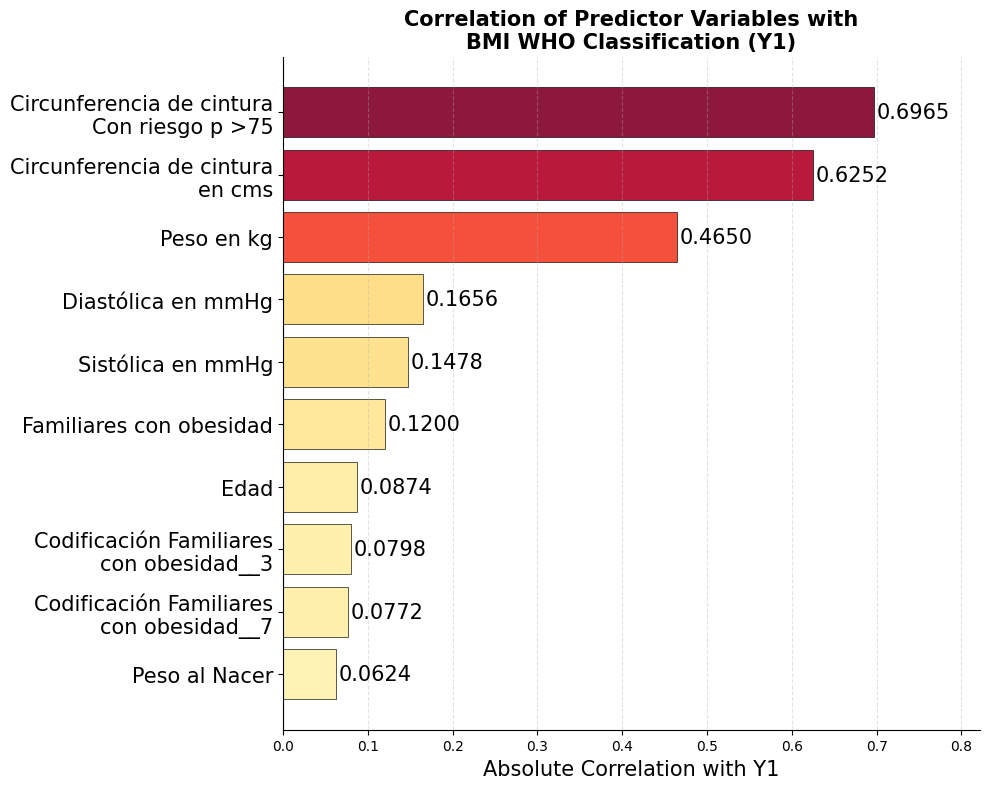

In [14]:
import textwrap

fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = X.corrwith(Y1).abs().sort_values(ascending=False).dropna()[0:10]
cmap = plt.cm.get_cmap('YlOrRd')
colors = [cmap(v / correlation_matrix.max()) for v in correlation_matrix.values]
ax.barh(range(len(correlation_matrix)), correlation_matrix.values,
        color=colors, edgecolor='black', linewidth=0.5, alpha=0.9)
ax.set_yticks(range(len(correlation_matrix)))

wrapped_labels = [textwrap.fill(label, width=25) for label in correlation_matrix.index]
ax.set_yticklabels(wrapped_labels, fontsize=15)

ax.set_xlabel("Absolute Correlation with Y1", fontsize=15)
ax.set_title("Correlation of Predictor Variables with\nBMI WHO Classification (Y1)", fontsize=15, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_xlim(0, correlation_matrix.max() * 1.18)  
for i, v in enumerate(correlation_matrix.values):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=15) 
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("correlacion_Y1.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\luill\AppData\Local\Temp\ipykernel_3284\260091908.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


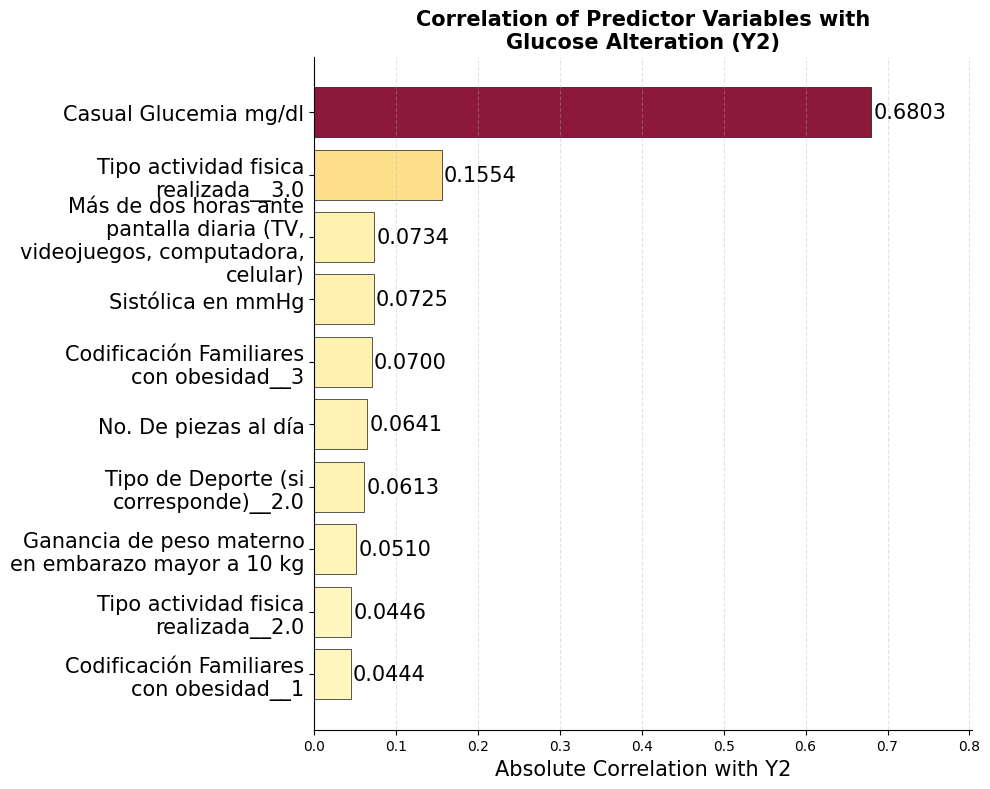

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = X.corrwith(Y2).abs().sort_values(ascending=False).dropna()[0:10]
cmap = plt.cm.get_cmap('YlOrRd')
colors = [cmap(v / correlation_matrix.max()) for v in correlation_matrix.values]
ax.barh(range(len(correlation_matrix)), correlation_matrix.values,
        color=colors, edgecolor='black', linewidth=0.5, alpha=0.9)
ax.set_yticks(range(len(correlation_matrix)))

wrapped_labels = [textwrap.fill(label, width=25) for label in correlation_matrix.index]
ax.set_yticklabels(wrapped_labels, fontsize=15)

ax.set_xlabel("Absolute Correlation with Y2", fontsize=15)
ax.set_title("Correlation of Predictor Variables with\nGlucose Alteration (Y2)", fontsize=15, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_xlim(0, correlation_matrix.max() * 1.18)  
for i, v in enumerate(correlation_matrix.values):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=15) 
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("correlacion_Y2.png", dpi=150, bbox_inches='tight')
plt.show()

C:\Users\luill\AppData\Local\Temp\ipykernel_3284\1381236224.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd')


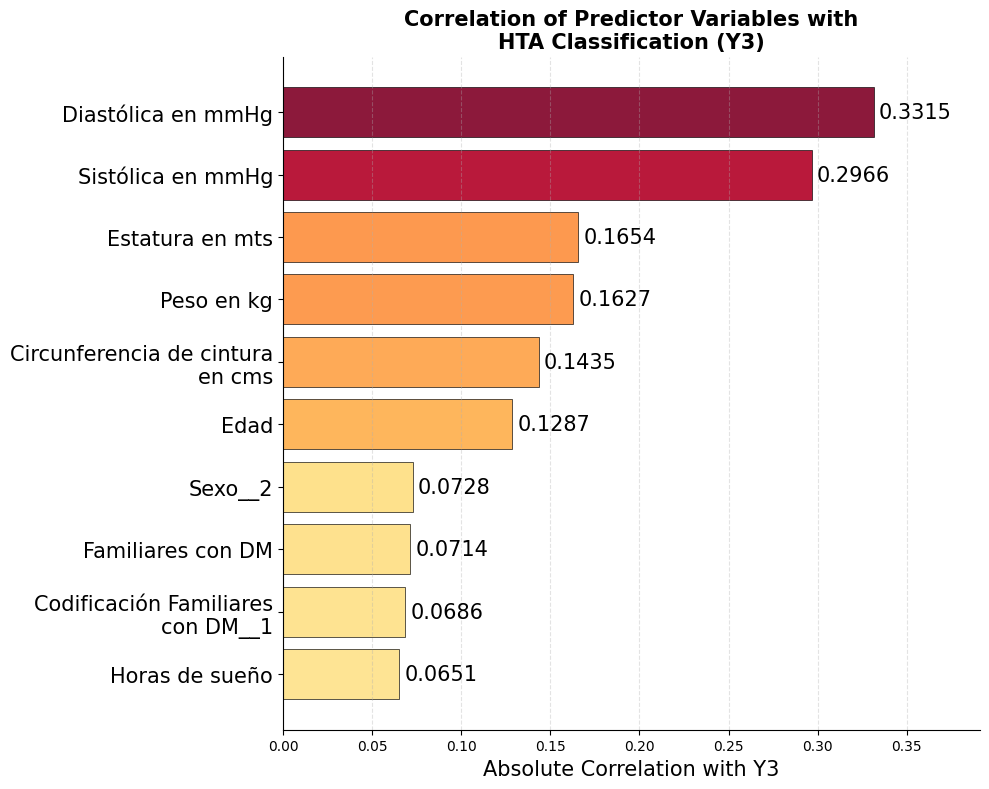

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
correlation_matrix = X.corrwith(Y3).abs().sort_values(ascending=False).dropna()[0:10]
cmap = plt.cm.get_cmap('YlOrRd')
colors = [cmap(v / correlation_matrix.max()) for v in correlation_matrix.values]
ax.barh(range(len(correlation_matrix)), correlation_matrix.values,
        color=colors, edgecolor='black', linewidth=0.5, alpha=0.9)
ax.set_yticks(range(len(correlation_matrix)))

wrapped_labels = [textwrap.fill(label, width=25) for label in correlation_matrix.index]
ax.set_yticklabels(wrapped_labels, fontsize=15)

ax.set_xlabel("Absolute Correlation with Y3", fontsize=15)
ax.set_title("Correlation of Predictor Variables with\nHTA Classification (Y3)", fontsize=15, fontweight='bold')
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_xlim(0, correlation_matrix.max() * 1.18)  
for i, v in enumerate(correlation_matrix.values):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=15) 
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("correlacion_Y3.png", dpi=150, bbox_inches='tight')
plt.show()


In [17]:
data.shape

(3293, 46)

In [18]:
for col in ['IMC        Kg/mts2']:
    merged = pd.concat([X, Y1, Y2, Y3], axis=1)
    cleaned = drop_outliers_iqr(merged, col)
    X = cleaned[X.columns]
    Y1 = cleaned[Y1.name]
    Y2 = cleaned[Y2.name]
    Y3 = cleaned[Y3.name]

In [19]:
data.shape

(3293, 46)

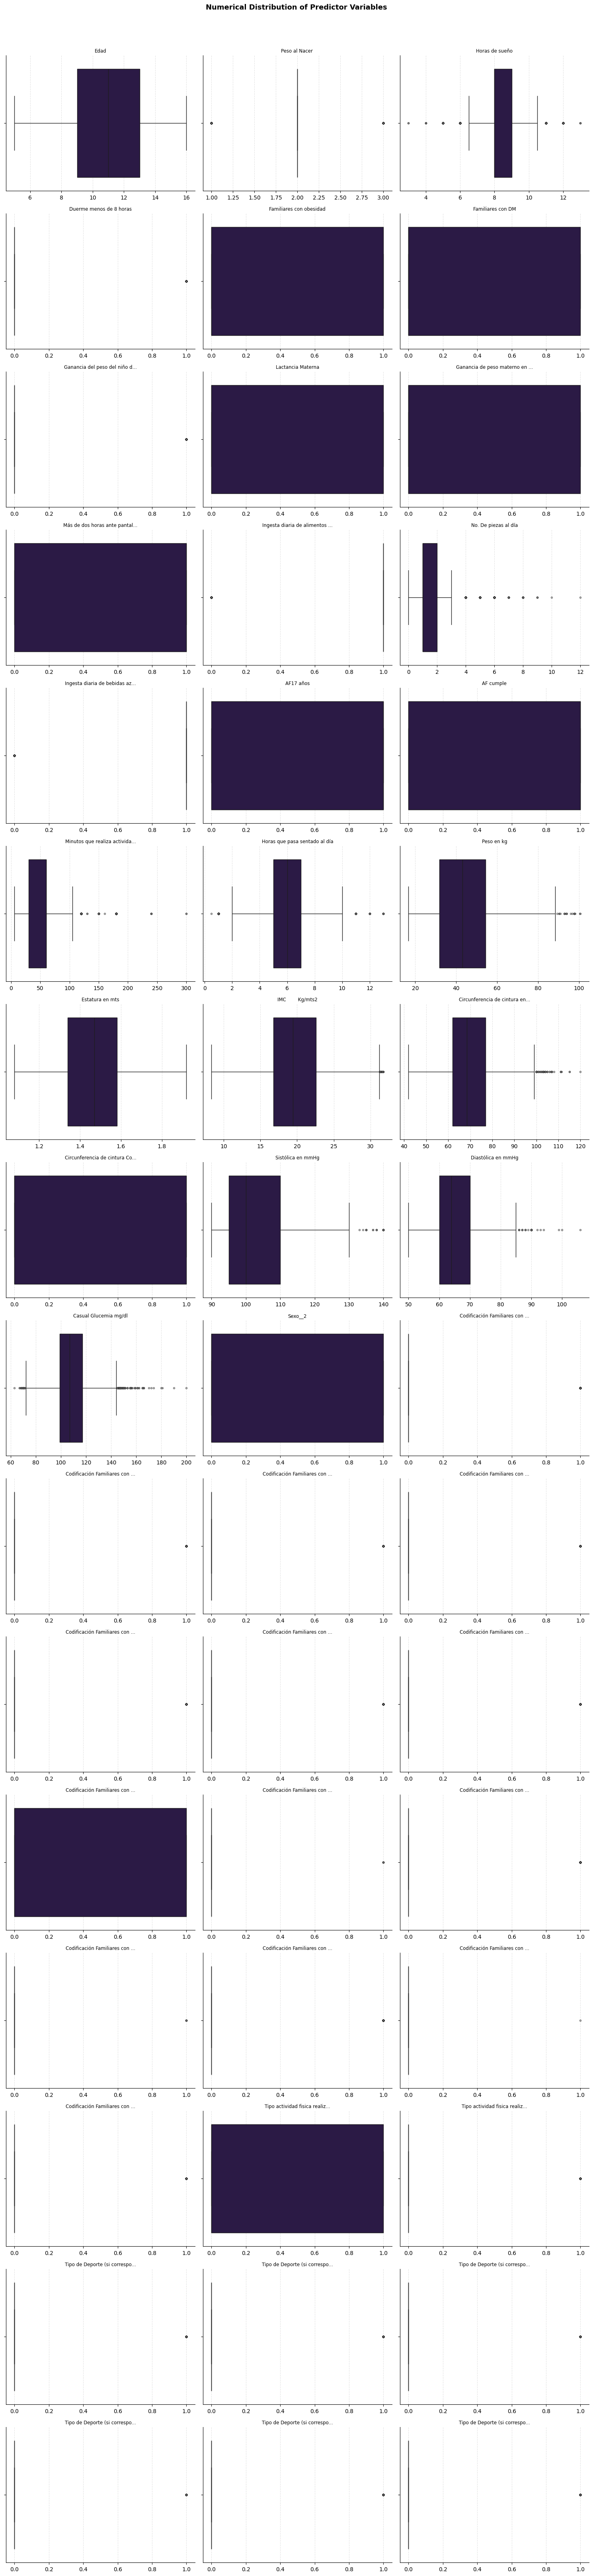

In [20]:
valid_columns = [col for col in X.columns
                 if pd.api.types.is_numeric_dtype(X[col]) and X[col].notna().any()]

n_cols = 3
n_rows = (len(valid_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
fig.suptitle("Numerical Distribution of Predictor Variables", fontsize=13, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, col in enumerate(valid_columns):
    sns.boxplot(x=X[col], ax=axes[i], color="#29134C", linewidth=1.0,
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5))
    axes[i].set_xlabel('')
    label = col if len(col) <= 30 else col[:28] + '...'
    axes[i].set_title(label, fontsize=8.5)
    axes[i].grid(axis='x', linestyle='--', alpha=0.35)
    for spine in ('top', 'right'):
        axes[i].spines[spine].set_visible(False)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("boxplots_variables.png", dpi=150, bbox_inches='tight')
plt.show()


In [21]:
X_nonan = X.loc[:, X.notna().any()]
column_names = X_nonan.columns

if X_nonan.isnull().any().any():
    imputer = SimpleImputer(strategy="median")
    imputer.fit(X_nonan)
    X_imputed = imputer.transform(X_nonan)
    X = pd.DataFrame(X_imputed, columns=column_names)
else:
    print("No se encontraron valores faltantes; no se aplica imputación.")

In [22]:
len(Y1)

3229

In [23]:
X_  = X.reset_index(drop=True)
Y1_ = Y1.reset_index(drop=True)
Y2_ = Y2.reset_index(drop=True)
Y3_ = Y3.reset_index(drop=True)

X_train, X_rest, Y1_train, Y1_rest, Y2_train, Y2_rest, Y3_train, Y3_rest = train_test_split(
    X_, Y1_, Y2_, Y3_,
    test_size=0.6, random_state=42, stratify=Y1_
)

X_test, X_val, Y1_test, Y1_val, Y2_test, Y2_val, Y3_test, Y3_val = train_test_split(
    X_rest, Y1_rest, Y2_rest, Y3_rest,
    test_size=0.5, random_state=42, stratify=Y1_rest
)


In [24]:
logreg_model = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model.fit(X_train, Y1_train)
metrics_df, roc_corner = metrics( logreg_model, X_train, X_test, X_val, Y1_train, Y1_test, Y1_val, Y1)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.769946  0.727554  0.720330
Precision (thr*)  0.705952  0.661517  0.660908
Recall (thr*)     0.729699  0.683305  0.677641
ROC AUC           0.933408  0.911294  0.912579

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.124266  0.170045  0.827160  0.242464
1      1   0.564121  0.225322  0.870775  0.259748
2      2   0.194896  0.241873  0.880000  0.270004
3      3   0.264780  0.070153  0.940541  0.091961


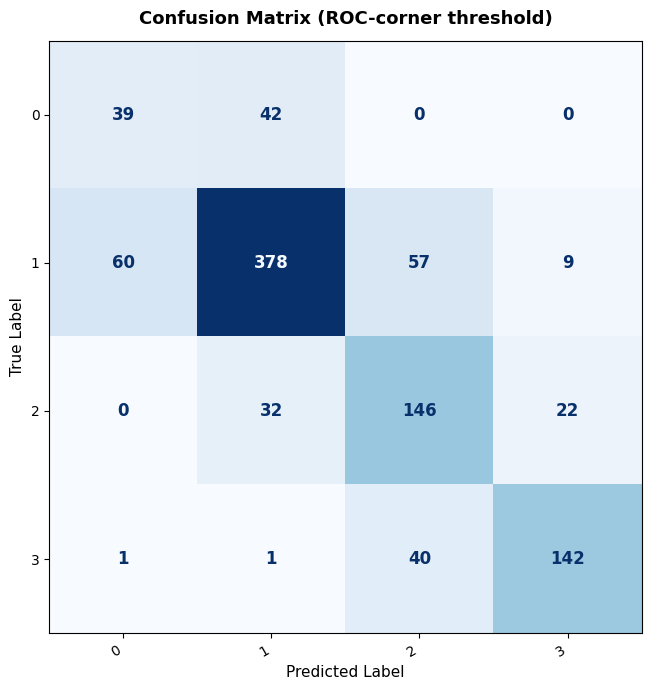

  Optimal thresholds per class (ROC corner):
    0: 0.1243
    1: 0.5641
    2: 0.1949
    3: 0.2648


In [25]:
confusion_matrix_mult(logreg_model, Y1_train, X_test, Y1_test, X_val, Y1_val)

In [26]:
coef_imp = lr_coef_importance(logreg_model, X_train,  multinomial_reference="first")
coef_imp = coef_imp[
    (coef_imp["p>|z|"] < 0.05) | (coef_imp["p>|z|"].isna())
].sort_values("abs_coef_std", ascending=False)
display(coef_imp)

c:\Users\luill\OneDrive\Documentos\Maestría Ciencia de Datos\Tesis\funciones.py:977: RuntimeWarning: invalid value encountered in divide
  z_theta   = theta / se_theta


,class,ref_class,feature,coef,odds_ratio,se,z,p>|z|,coef_std,abs_coef_std,or_per_sd
144,3,0,IMC Kg/mts2,2.431263,11.373237,0.320573,7.584125,3.352874e-14,9.904924,9.904924,20028.742380
96,2,0,IMC Kg/mts2,1.621156,5.058934,0.279983,5.790187,7.030826e-09,6.604561,6.604561,738.455405
145,3,0,Edad,-2.095639,0.122992,0.193416,-10.834883,0.000000e+00,-6.092407,6.092407,0.002260
0,0,baseline,IMC Kg/mts2,-1.154304,0.315277,NaN,NaN,NaN,-4.702617,4.702617,0.009072
97,2,0,Edad,-1.179085,0.307560,0.144004,-8.187854,2.220446e-16,-3.427817,3.427817,0.032458
...,...,...,...,...,...,...,...,...,...,...,...
46,0,baseline,Codificación Familiares con DM__4,-0.025338,0.974980,NaN,NaN,NaN,-0.000705,0.000705,0.999295
47,0,baseline,Codificación Familiares con DM__6,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000,1.000000
95,1,0,Codificación Familiares con DM__6,0.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,1.000000
143,2,0,Codificación Familiares con DM__6,0.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,1.000000


In [27]:
logreg_model2 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model2.fit(X_train, Y2_train)
metrics_df, roc_corner = metrics( logreg_model2, X_train, X_test, X_val, Y2_train, Y2_test, Y2_val, Y2)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.952750  0.928793  0.927761
Precision (thr*)  0.986547  0.970149  0.968563
Recall (thr*)     0.947255  0.929900  0.929598
ROC AUC           0.993232  0.983405  0.981943

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      1   0.643651  0.076923  0.929598  0.104277


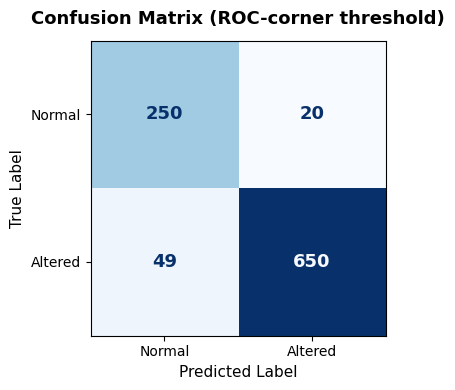

  Optimal threshold (ROC corner): 0.6437


In [28]:
confusion_matrix_binary(logreg_model2, X_test, Y2_test, X_val, Y2_val)

In [29]:
coef_imp2 = lr_coef_importance(logreg_model2, X_train,  multinomial_reference="first")
coef_imp2 = coef_imp2[
    (coef_imp2["p>|z|"] < 0.05) | (coef_imp2["p>|z|"].isna())
].sort_values("abs_coef_std", ascending=False)
display(coef_imp2)

c:\Users\luill\OneDrive\Documentos\Maestría Ciencia de Datos\Tesis\funciones.py:893: RuntimeWarning: invalid value encountered in divide
  z    = beta / se


,feature,coef,odds_ratio,se,z,p>|z|,coef_std,abs_coef_std,or_per_sd
0,Casual Glucemia mg/dl,0.571923,1.771671,0.047593,12.017025,0.000000,8.735139,8.735139,6217.599467
1,Peso en kg,0.194624,1.214854,0.066037,2.947178,0.003207,3.026430,3.026430,20.623481
2,IMC Kg/mts2,-0.367892,0.692192,0.152989,-2.404688,0.016186,-1.498785,1.498785,0.223401
3,Circunferencia de cintura en cms,-0.104828,0.900479,0.027560,-3.803674,0.000143,-1.212367,1.212367,0.297492
4,Diastólica en mmHg,-0.094690,0.909655,0.024048,-3.937590,0.000082,-0.717756,0.717756,0.487846
5,"Más de dos horas ante pantalla diaria (TV, vid...",-1.465776,0.230899,0.340291,-4.307416,0.000017,-0.698104,0.698104,0.497527
6,Horas de sueño,-0.546164,0.579167,0.173200,-3.153375,0.001614,-0.666701,0.666701,0.513399
7,Circunferencia de cintura Con riesgo p >75,1.401350,4.060679,0.546328,2.565036,0.010317,0.657734,0.657734,1.930414
8,Duerme menos de 8 horas,-1.445399,0.235652,0.508512,-2.842410,0.004477,-0.575455,0.575455,0.562449
47,Codificación Familiares con DM__6,0.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,1.000000


In [30]:
logreg_model3 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=3000)
logreg_model3.fit(X_train, Y3_train)
metrics_df, roc_corner = metrics( logreg_model3, X_train, X_test, X_val, Y3_train, Y3_test, Y3_val, Y3)
print(metrics_df)
print("\nROC corner thresholds (desde VALIDACIÓN):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.696359  0.597523  0.616099
Precision (thr*)  0.548822  0.434784  0.476374
Recall (thr*)     0.674592  0.544291  0.562731
ROC AUC           0.868768  0.795712  0.803588

ROC corner thresholds (desde VALIDACIÓN):
   class  threshold       FPR       TPR  distance
0      0   0.730459  0.342857  0.799710  0.397073
1      1   0.089250  0.099562  0.836364  0.191545
2      2   0.079428  0.134463  0.916667  0.158192
3      3   0.094669  0.463768  0.617021  0.601460


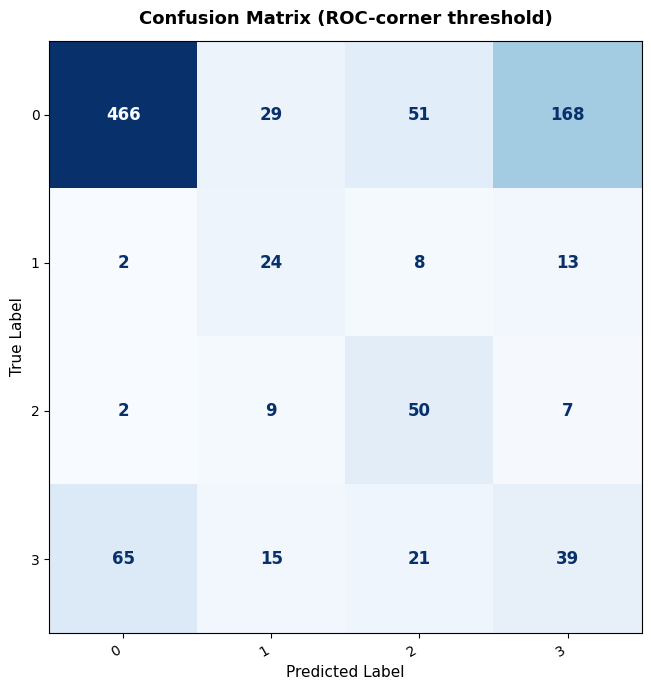

  Optimal thresholds per class (ROC corner):
    0: 0.7305
    1: 0.0893
    2: 0.0794
    3: 0.0947


In [31]:
confusion_matrix_mult(logreg_model3, Y3_train, X_test, Y3_test, X_val, Y3_val)

In [32]:
coef_imp3 = lr_coef_importance(logreg_model3, X_train,  multinomial_reference="first")
coef_imp3 = coef_imp3[
    (coef_imp3["p>|z|"] < 0.05) | (coef_imp3["p>|z|"].isna())
].sort_values("abs_coef_std", ascending=False)
display(coef_imp3)

c:\Users\luill\OneDrive\Documentos\Maestría Ciencia de Datos\Tesis\funciones.py:977: RuntimeWarning: invalid value encountered in divide
  z_theta   = theta / se_theta


,class,ref_class,feature,coef,odds_ratio,se,z,p>|z|,coef_std,abs_coef_std,or_per_sd
96,2,0,Diastólica en mmHg,0.345792,1.413109,0.030928,11.180601,0.000000,2.621123,2.621123,13.751152
48,1,0,Peso en kg,0.157321,1.170372,0.064731,2.430394,0.015082,2.446368,2.446368,11.546338
97,2,0,Peso en kg,0.153446,1.165845,0.068108,2.252972,0.024261,2.386113,2.386113,10.871156
49,1,0,Sistólica en mmHg,0.222854,1.249638,0.022174,10.050106,0.000000,2.309762,2.309762,10.072030
50,1,0,Circunferencia de cintura en cms,-0.121753,0.885367,0.039451,-3.086209,0.002027,-1.408105,1.408105,0.244606
...,...,...,...,...,...,...,...,...,...,...,...
46,0,baseline,Ganancia del peso del niño de más de > 10 kg e...,-0.005979,0.994039,NaN,NaN,NaN,-0.002412,0.002412,0.997591
47,0,baseline,Codificación Familiares con DM__6,0.000000,1.000000,NaN,NaN,NaN,0.000000,0.000000,1.000000
95,1,0,Codificación Familiares con DM__6,0.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,1.000000
143,2,0,Codificación Familiares con DM__6,0.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,1.000000


  Saved: importancia_coeficientes_BMI_Classification.png


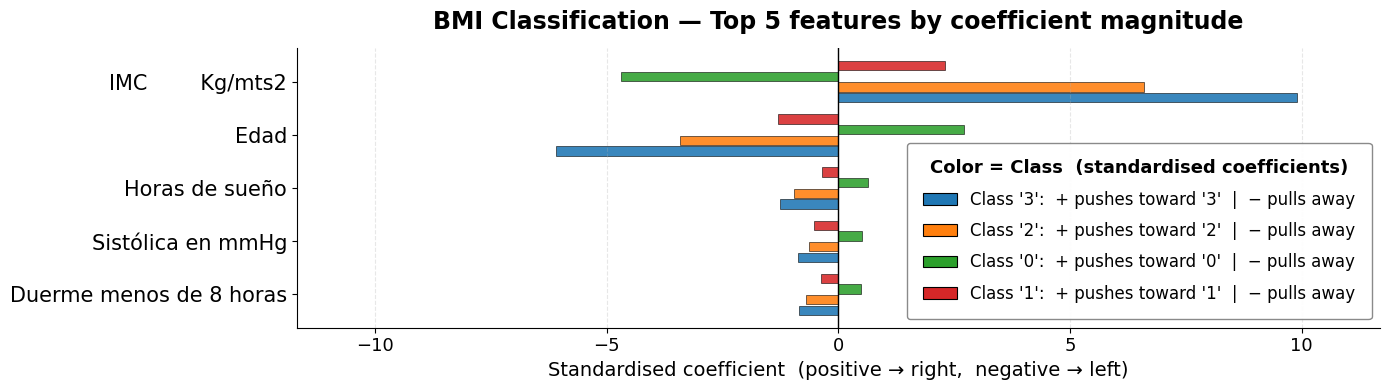

  Saved: importancia_coeficientes_Glucose_Alteration.png


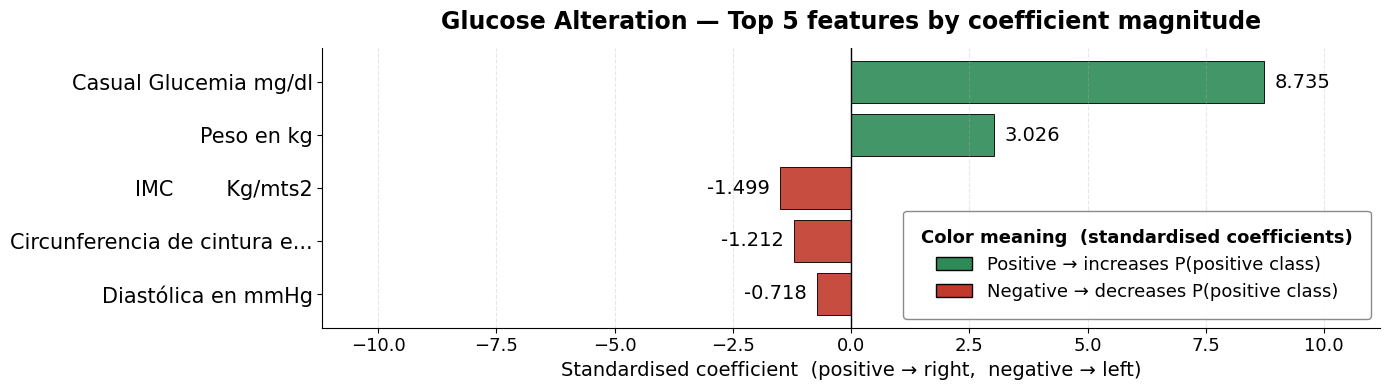

  Saved: importancia_coeficientes_HTA_Classification.png


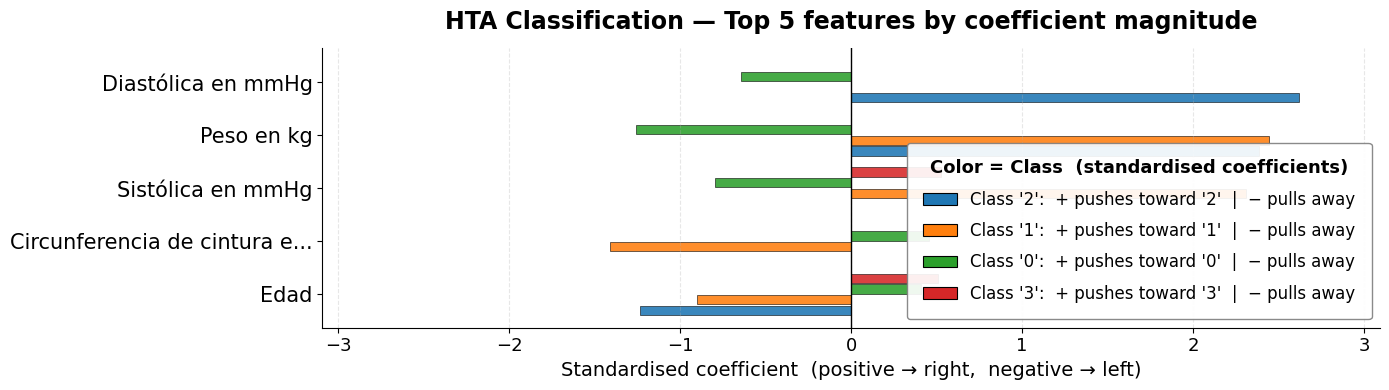

In [33]:
plot_logreg_coefs_panel_safe(coef_imp,     "BMI Classification")
plot_logreg_coefs_panel_safe(coef_imp2, "Glucose Alteration")
plot_logreg_coefs_panel_safe(coef_imp3, "HTA Classification")

### ROC Curves — Logistic Regression
ROC Curves One-vs-Rest (multiclass) and standard ROC curve (binary) calculated on the test set for the three logistic regression models.

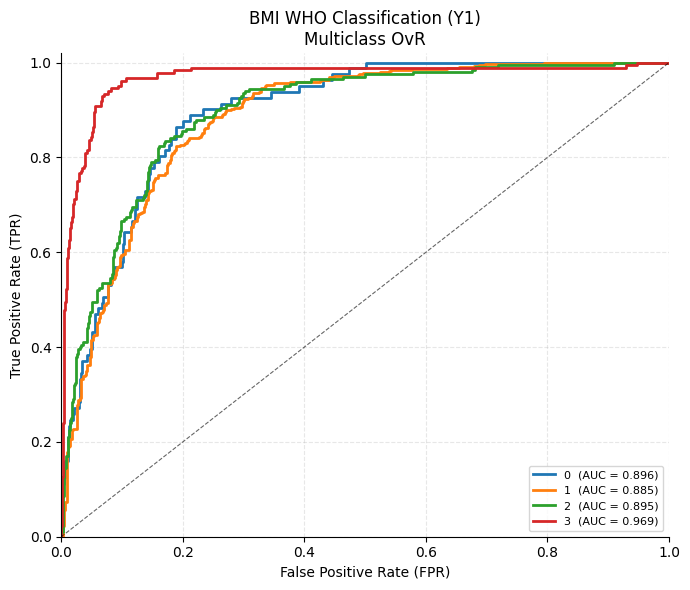

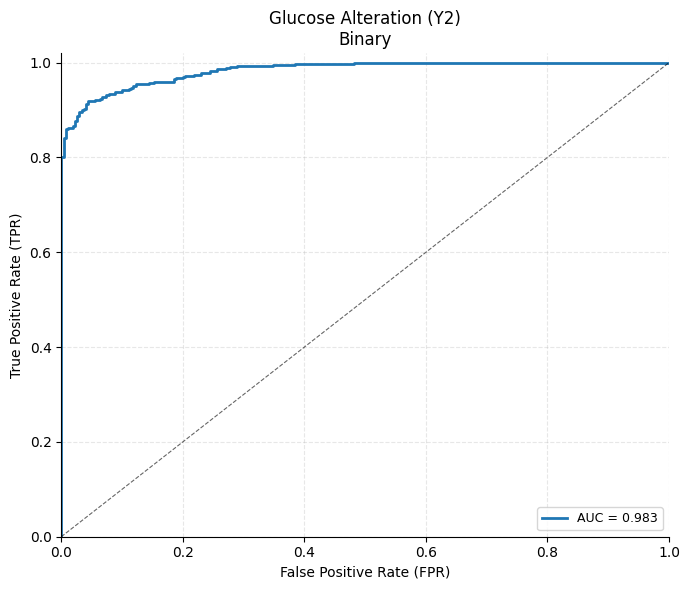

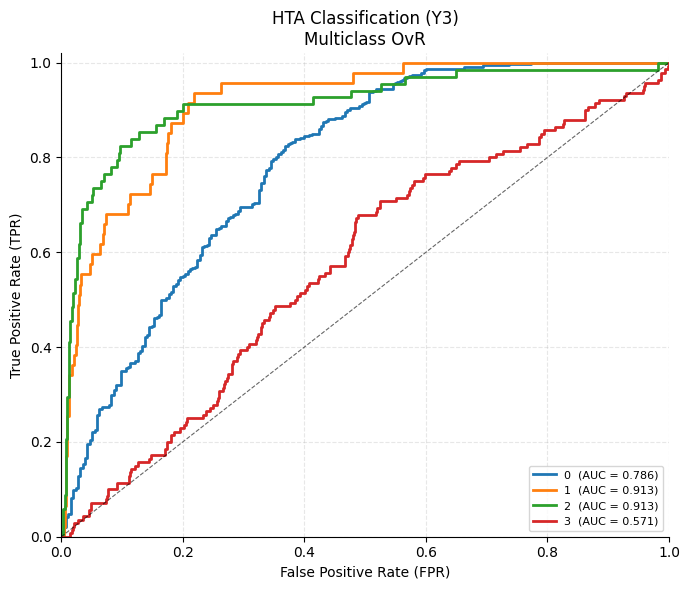

In [34]:
_roc_multiclass(logreg_model,  X_test, Y1_test,
                "BMI WHO Classification (Y1)\nMulticlass OvR",
                "LogRegSimpleY1")
_roc_binary(logreg_model2, X_test, Y2_test,
                "Glucose Alteration (Y2)\nBinary",
                "LogRegSimpleY2")
_roc_multiclass(logreg_model3, X_test, Y3_test,
                "HTA Classification (Y3)\nMulticlass OvR",
                "LogRegSimpleY3")

# `Remove non-significant variables from X`

In [35]:
_df1 = coef_imp[(coef_imp["p>|z|"] < 0.05)]
_imp1 = _df1.groupby("feature")["abs_coef_std"].mean().sort_values(ascending=False)
significant_features_Y1 = _imp1.index

_df2 = coef_imp2[coef_imp2["p>|z|"] < 0.05]
significant_features_Y2 = _df2.sort_values("abs_coef_std", ascending=False)["feature"]

_df3 = coef_imp3[(coef_imp3["p>|z|"] < 0.05)]
_imp3 = _df3.groupby("feature")["abs_coef_std"].mean().sort_values(ascending=False)
significant_features_Y3 = _imp3.index

print(f"Y1 selected features: {significant_features_Y1.unique()}, {len(significant_features_Y1.unique())}")
print(f"Y2 selected features: {significant_features_Y2.unique()}, {len(significant_features_Y2.unique())}")
print(f"Y3 selected features: {significant_features_Y3.unique()}, {len(significant_features_Y3.unique())}")

Y1 selected features: Index(['IMC        Kg/mts2', 'Edad', 'Horas de sueño', 'Sistólica en mmHg',
       'Duerme menos de 8 horas', 'Peso al Nacer ',
       'Horas que pasa sentado al día'],
      dtype='object', name='feature'), 7
Y2 selected features: ['Casual Glucemia mg/dl' 'Peso en kg' 'IMC        Kg/mts2'
 'Circunferencia de cintura en cms' 'Diastólica en mmHg'
 'Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)'
 'Horas de sueño' 'Circunferencia de cintura Con riesgo p >75'
 'Duerme menos de 8 horas'], 9
Y3 selected features: Index(['Diastólica en mmHg', 'Peso en kg', 'Sistólica en mmHg',
       'Circunferencia de cintura en cms', 'Edad', 'Sexo__2',
       'Ingesta diaria de alimentos de alto contenido calórico Más de 2 veces por semana',
       'No. De piezas al día', 'Casual Glucemia mg/dl',
       'Circunferencia de cintura Con riesgo p >75',
       'Tipo de Deporte (si corresponde)__3.0',
       'Codificación Familiares con DM__3'],
      dtype='o

In [36]:
X_train_significant1 = X_train[list(set(significant_features_Y1))]
X_test_significant1 = X_test[list(set(significant_features_Y1))]
X_val_significant1 = X_val[list(set(significant_features_Y1))]

X_train_significant2 = X_train[list(set(significant_features_Y2))]
X_test_significant2 = X_test[list(set(significant_features_Y2))]
X_val_significant2 = X_val[list(set(significant_features_Y2))]

X_train_significant3 = X_train[list(set(significant_features_Y3))]
X_test_significant3 = X_test[list(set(significant_features_Y3))]
X_val_significant3 = X_val[list(set(significant_features_Y3))]

X_train_significant2.head()

,Casual Glucemia mg/dl,Horas de sueño,Diastólica en mmHg,IMC Kg/mts2,Circunferencia de cintura en cms,Peso en kg,"Más de dos horas ante pantalla diaria (TV, videojuegos, computadora, celular)",Duerme menos de 8 horas,Circunferencia de cintura Con riesgo p >75
496,100.0,8.0,62.0,14.177778,64.0,31.9,0.0,0.0,0.0
2367,111.0,7.0,80.0,25.209201,93.0,72.0,1.0,1.0,1.0
2695,161.0,8.0,70.0,20.174554,74.0,46.0,1.0,0.0,1.0
1441,123.0,12.0,60.0,19.341401,69.0,39.0,0.0,0.0,0.0
3098,86.0,8.0,60.0,17.301038,62.0,32.0,1.0,0.0,0.0


In [37]:
logreg_model_est = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model_est.fit(X_train_significant1, Y1_train)
metrics_df, roc_corner = metrics( logreg_model_est, X_train_significant1, X_test_significant1, X_val_significant1, Y1_train, Y1_test, Y1_val, Y1)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.776917  0.760578  0.744066
Precision (thr*)  0.707107  0.689937  0.672579
Recall (thr*)     0.744836  0.724839  0.703851
ROC AUC           0.926904  0.918817  0.912882

ROC corner thresholds (val):
   class  threshold       FPR       TPR  distance
0      0   0.084562  0.221847  0.814815  0.288980
1      1   0.615913  0.195279  0.844930  0.249360
2      2   0.298478  0.148244  0.875000  0.193911
3      3   0.241934  0.080357  0.962162  0.088820


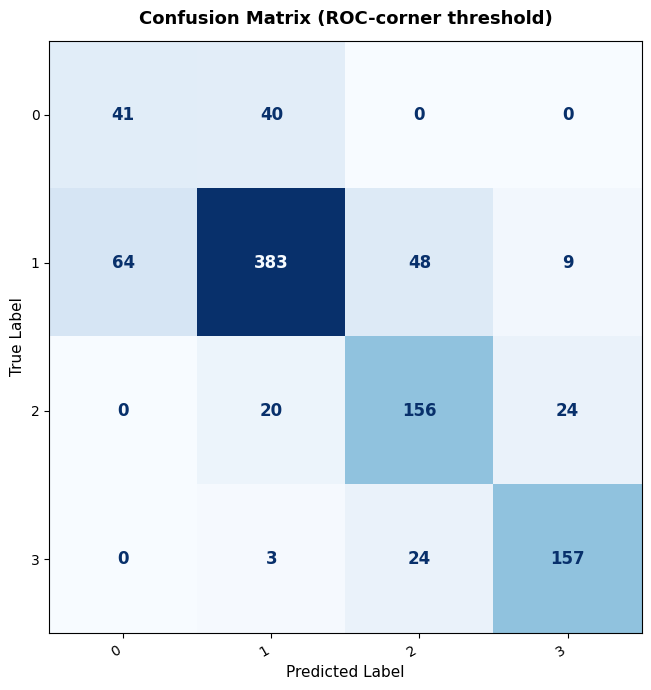

  Optimal thresholds per class (ROC corner):
    0: 0.0846
    1: 0.6159
    2: 0.2985
    3: 0.2419


In [38]:
confusion_matrix_mult(logreg_model_est, Y1_train, X_test_significant1, Y1_test, X_val_significant1, Y1_val)

In [39]:
logreg_model2_est = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model2_est.fit(X_train_significant2, Y2_train)
metrics_df, roc_corner = metrics( logreg_model2_est, X_train_significant2, X_test_significant2, X_val_significant2, Y2_train, Y2_test, Y2_val, Y2)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)
logreg_model2_est.coef_

                     Train      Test  Val
Accuracy (thr*)   0.998451  0.996904  1.0
Precision (thr*)  1.000000  1.000000  1.0
Recall (thr*)     0.997847  0.995708  1.0
ROC AUC           1.000000  1.000000  1.0

ROC corner thresholds (val):
   class  threshold  FPR  TPR  distance
0      1   0.860737  0.0  1.0       0.0


array([[ 4.30028029e+00, -4.03524684e-02, -3.49206720e-02,
         2.64366160e-02, -3.38299743e-03, -2.37559335e-03,
        -3.01668175e-01,  3.50542452e-02, -1.69255555e-01]])

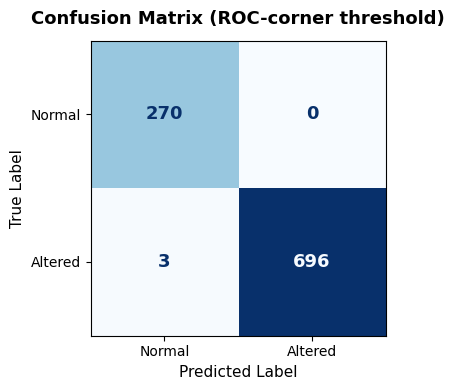

  Optimal threshold (ROC corner): 0.8607


In [40]:
confusion_matrix_binary(logreg_model2_est, X_test_significant2, Y2_test, X_val_significant2, Y2_val)

In [41]:
logreg_model3_est = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_model3_est.fit(X_train_significant3, Y3_train)
metrics_df, roc_corner = metrics( logreg_model3_est, X_train_significant3, X_test_significant3, X_val_significant3, Y3_train, Y3_test, Y3_val, Y3)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

                     Train      Test       Val
Accuracy (thr*)   0.589466  0.545924  0.555212
Precision (thr*)  0.452526  0.402701  0.428190
Recall (thr*)     0.585223  0.526440  0.533373
ROC AUC           0.840475  0.785318  0.792415

ROC corner thresholds (val):
   class  threshold       FPR       TPR  distance
0      0   0.783152  0.275000  0.690856  0.413757
1      1   0.053244  0.172867  0.836364  0.238033
2      2   0.097084  0.141243  0.833333  0.218466
3      3   0.108990  0.435990  0.624113  0.575655


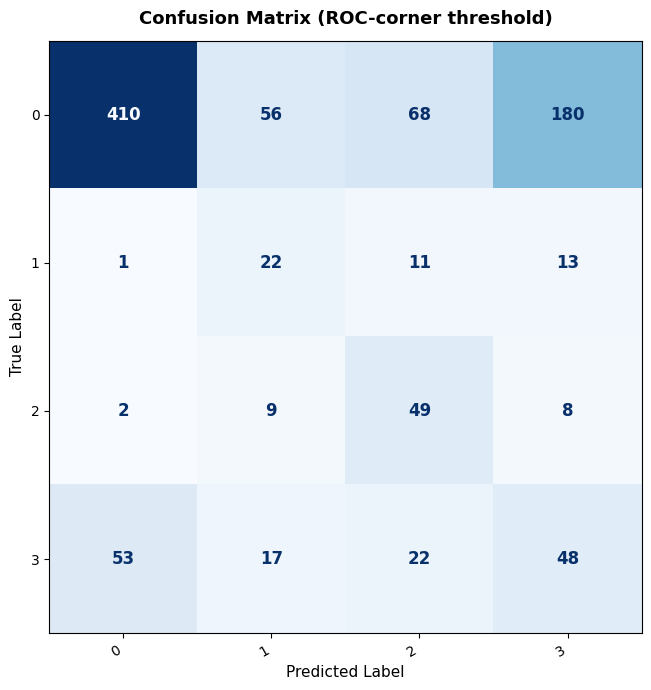

  Optimal thresholds per class (ROC corner):
    0: 0.7832
    1: 0.0532
    2: 0.0971
    3: 0.1090


In [42]:
confusion_matrix_mult(logreg_model3_est, Y3_train, X_test_significant3, Y3_test, X_val_significant3, Y3_val)

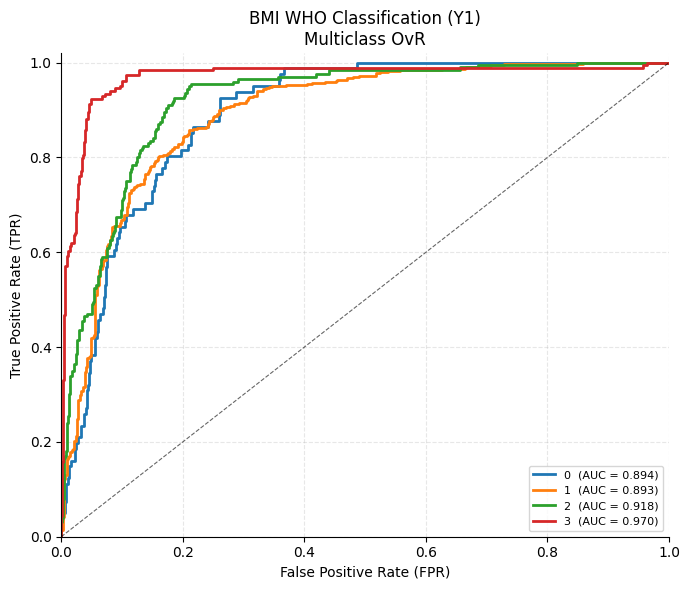

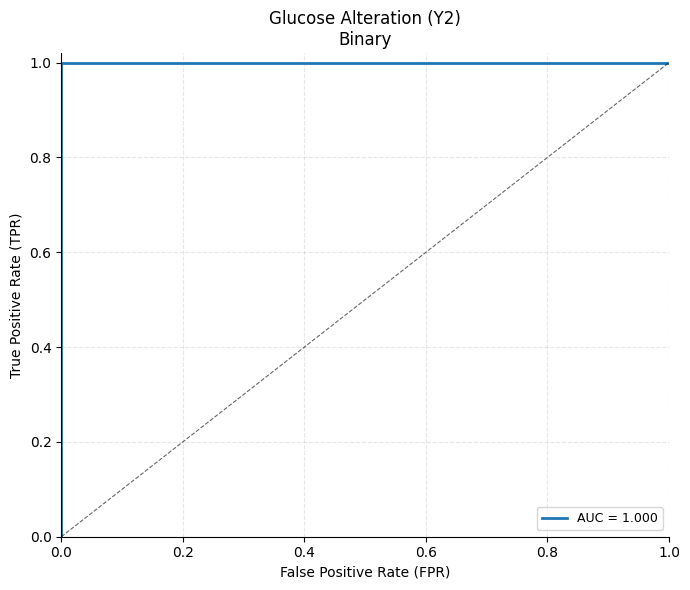

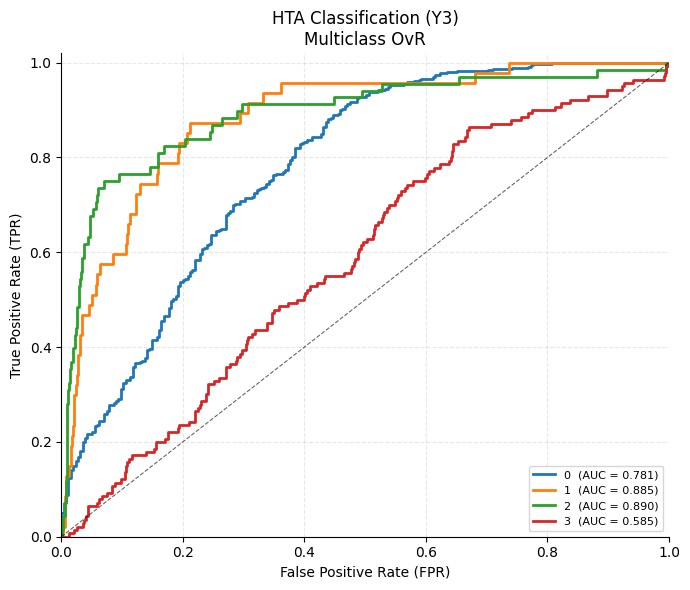

In [43]:
_roc_multiclass(logreg_model_est,  X_test_significant1, Y1_test,
                "BMI WHO Classification (Y1)\nMulticlass OvR",
                "LogRegSimpleSignY1")
_roc_binary(logreg_model2_est, X_test_significant2, Y2_test,
                "Glucose Alteration (Y2)\nBinary",
                "LogRegSimpleSignY2")
_roc_multiclass(logreg_model3_est, X_test_significant3, Y3_test,
                "HTA Classification (Y3)\nMulticlass OvR",
                "LogRegSimpleSignY3")

# `SVM as a comparison model`

In [ ]:
search1 = svc_hiper_search_mult(X_train_significant1, Y1_train)
best_model1 = search1.best_estimator_
print("Best hyperparameters:", search1.best_params_)
print("Best f1_macro (CV):", search1.best_score_)

metrics_df, roc_corner = metrics( best_model1, X_train_significant1, X_test_significant1, X_val_significant1, Y1_train, Y1_test, Y1_val, Y1)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

Fitting 3 folds for each of 100 candidates, totalling 300 fits


In [ ]:
confusion_matrix_mult(best_model1, Y1_train, X_test_significant1, Y1_test, X_val_significant1, Y1_val)

In [ ]:
search2 = svc_hiper_search_binary(X_train_significant2, Y2_train)
best_model2 = search2.best_estimator_
print("Best hyperparameters:", search2.best_params_)
print("Best f1_macro (CV):", search2.best_score_)

metrics_df, roc_corner = metrics( best_model2, X_train_significant2, X_test_significant2, X_val_significant2, Y2_train, Y2_test, Y2_val, Y2)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_binary(best_model2, X_test_significant2, Y2_test, X_val_significant2, Y2_val)

In [ ]:
search3 = svc_hiper_search_mult(X_train_significant3, Y3_train)
best_model3 = search3.best_estimator_
print("Best hyperparameters:", search3.best_params_)
print("Best f1_macro (CV):", search3.best_score_)

# 7) Evalúa con tu función (recuerda: Test quedó limpio)
metrics_df, roc_corner = metrics( best_model3, X_train_significant3, X_test_significant3, X_val_significant3, Y3_train, Y3_test, Y3_val, Y3)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_mult(best_model3, Y3_train, X_test_significant3, Y3_test, X_val_significant3, Y3_val)

### ROC Curves — SVM

ROC Curves One-vs-Rest for the SVM models trained with the significant variables of each target.

In [ ]:
_roc_multiclass(best_model1,  X_test_significant1, Y1_test,
                "BMI WHO Classification (Y1)\nMulticlass OvR",
                "SVMSimpleSignY1")
_roc_binary(best_model2, X_test_significant2, Y2_test,
                "Glucose Alteration (Y2)\nBinary",
                "SVMSimpleSignY2")
_roc_multiclass(best_model3, X_test_significant3, Y3_test,
                "HTA Classification (Y3)\nMulticlass OvR",
                "SVMSimpleSignY3")

# `First Approximation of SMOTE for Imbalance Handling`

In [ ]:
X1_sm, Y1_sm = smote_fit_resample(X[significant_features_Y1], Y1, ratio=1.0, sampler="kmeans", clean="none", k_neighbors=1, random_state=42, verbose=True)
X1_train_sm, X1_rest_sm, Y1_train_sm, Y1_rest_sm = train_test_split(X1_sm, Y1_sm, test_size=0.6, random_state=42, stratify=Y1_sm)
X1_test_sm, X1_val_sm, Y1_test_sm, Y1_val_sm, = train_test_split(X1_rest_sm, Y1_rest_sm,test_size=0.5, random_state=42, stratify=Y1_rest_sm)

X2_sm, Y2_sm = smote_fit_resample(X[significant_features_Y2], Y2,ratio=1.0, sampler="kmeans", clean="none", k_neighbors=1, random_state=42, verbose=True)
X2_train_sm, X2_rest_sm, Y2_train_sm, Y2_rest_sm = train_test_split(X2_sm, Y2_sm, test_size=0.6, random_state=42, stratify=Y2_sm)
X2_test_sm, X2_val_sm, Y2_test_sm, Y2_val_sm, = train_test_split(X2_rest_sm, Y2_rest_sm,test_size=0.5, random_state=42, stratify=Y2_rest_sm)

X3_sm, Y3_sm = smote_fit_resample(X[significant_features_Y3], Y3,ratio=1.0, sampler="kmeans", clean="none", k_neighbors=1, random_state=42, verbose=True)
X3_train_sm, X3_rest_sm, Y3_train_sm, Y3_rest_sm = train_test_split(X3_sm, Y3_sm, test_size=0.6, random_state=42, stratify=Y3_sm)
X3_test_sm, X3_val_sm, Y3_test_sm, Y3_val_sm, = train_test_split(X3_rest_sm, Y3_rest_sm,test_size=0.5, random_state=42, stratify=Y3_rest_sm)


### Class Distribution — Before and After SMOTE

Comparison of the frequency of each class before and after applying synthetic oversampling.

In [ ]:
pairs = [
    (Y1, Y1_sm, "IMC OMS (Y1)"),
    (Y2, Y2_sm, "Glucose Alteration (Y2)"),
    (Y3, Y3_sm, "HTA Classification (Y3)"),
]

for y_orig, y_smote, title in pairs:

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.suptitle("Class Distribution — Original vs SMOTE",
                 fontsize=13, fontweight='bold', y=1.02)

    orig_counts  = pd.Series(y_orig).value_counts().sort_index()
    smote_counts = pd.Series(y_smote).value_counts().sort_index()
    all_classes  = sorted(set(orig_counts.index) | set(smote_counts.index))
    orig_vals    = [orig_counts.get(c, 0)  for c in all_classes]
    smote_vals   = [smote_counts.get(c, 0) for c in all_classes]

    x  = np.arange(len(all_classes))
    w  = 0.35
    b1 = ax.bar(x - w/2, orig_vals,  w, label='Original', color='#4C8BE2',
                edgecolor='black', linewidth=0.6, alpha=0.9)
    b2 = ax.bar(x + w/2, smote_vals, w, label='SMOTE',    color='#E2844C',
                edgecolor='black', linewidth=0.6, alpha=0.9)

    ax.set_xticks(x)
    xlabels = [str(c)[:15] for c in all_classes]
    ax.set_xticklabels(xlabels, rotation=20, ha='right', fontsize=8.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5, str(int(h)),
                    ha='center', va='bottom', fontsize=7.5)

    plt.tight_layout()
    filename = f"distribucion_clases_smote_{title.replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f"  Saved: {filename}")
    plt.show()


In [ ]:
logreg_smote1 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_smote1.fit(X1_train_sm, Y1_train_sm)
metrics_df, roc_corner = metrics(logreg_smote1, X1_train_sm, X1_test_sm, X1_val_sm, Y1_train_sm, Y1_test_sm, Y1_val_sm, Y1_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_mult(logreg_smote1, Y1_train_sm, X1_test_sm, Y1_test_sm, X1_val_sm, Y1_val_sm)

In [ ]:
logreg_smote2 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_smote2.fit(X2_train_sm, Y2_train_sm)
metrics_df, roc_corner = metrics(logreg_smote2, X2_train_sm, X2_test_sm, X2_val_sm, Y2_train_sm, Y2_test_sm, Y2_val_sm, Y2_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_binary(logreg_smote2, X2_test_sm, Y2_test_sm, X2_val_sm, Y2_val_sm)

In [ ]:
logreg_smote3 = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
logreg_smote3.fit(X3_train_sm, Y3_train_sm)
metrics_df, roc_corner = metrics(logreg_smote3, X3_train_sm, X3_test_sm, X3_val_sm, Y3_train_sm, Y3_test_sm, Y3_val_sm, Y3_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_mult(logreg_smote3, Y3_train_sm, X3_test_sm, Y3_test_sm, X3_val_sm, Y3_val_sm)

In [ ]:
search1 = svc_hiper_search_mult(X1_train_sm, Y1_train_sm)
svc_smote1 = search1.best_estimator_
print("Best hyperparameters:", search1.best_params_)
print("Best f1_macro (CV):", search1.best_score_)

metrics_df, roc_corner = metrics(svc_smote1, X1_train_sm, X1_test_sm, X1_val_sm, Y1_train_sm, Y1_test_sm, Y1_val_sm, Y1_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_mult(svc_smote1, Y1_train_sm, X1_test_sm, Y1_test_sm, X1_val_sm, Y1_val_sm)

In [ ]:
search2 = svc_hiper_search_binary(X2_train_sm, Y2_train_sm)
svc_smote2 = search2.best_estimator_
print("Best hyperparameters:", search2.best_params_)
print("Best f1_macro (CV):", search2.best_score_)

metrics_df, roc_corner = metrics(svc_smote2, X2_train_sm, X2_test_sm, X2_val_sm, Y2_train_sm, Y2_test_sm, Y2_val_sm, Y2_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_binary(svc_smote2, X2_test_sm, Y2_test_sm, X2_val_sm, Y2_val_sm)

In [ ]:
search3 = svc_hiper_search_mult(X3_train_sm, Y3_train_sm)
svc_smote3 = search3.best_estimator_
print("Best hyperparameters:", search3.best_params_)
print("Best f1_macro (CV):", search3.best_score_)

metrics_df, roc_corner = metrics(svc_smote3, X3_train_sm, X3_test_sm, X3_val_sm, Y3_train_sm, Y3_test_sm, Y3_val_sm, Y3_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_mult(svc_smote3, Y3_train_sm, X3_test_sm, Y3_test_sm, X3_val_sm, Y3_val_sm)

### ROC Curves — SMOTE SVM

ROC Curves One-vs-Rest for the SVM models trained on data augmented with SMOTE.

In [ ]:
_roc_multiclass(svc_smote1,  X1_test_sm, Y1_test_sm,
                "BMI WHO Classification (Y1)\nMulticlass OvR",
                "SVMSMOTESignY1")
_roc_binary(svc_smote2, X2_test_sm, Y2_test_sm,
                "Glucose Alteration (Y2)\nBinary",
                "SVMSMOTESignY2")
_roc_multiclass(svc_smote3, X3_test_sm, Y3_test_sm,
                "HTA Classification (Y3)\nMulticlass OvR",
                "SVMSMOTESignY3")


# `Cluster`

In [ ]:
model_htA1 = train_cluster_then_classify(X1_train_sm, Y1_train_sm,
                                        clusterer="kmeans", k_range=(2, 8),
                                        # opcional: puedes pasar tu SVC/LR ya configurado:
                                        # base_estimator = svc_smote1#base_estimator=LogisticRegression(max_iter=2000)
                                        )

metrics_df, roc_corner = metrics( model_htA1, X1_train_sm, X1_test_sm, X1_val_sm, Y1_train_sm, Y1_test_sm, Y1_val_sm, Y1_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_mult(model_htA1, Y1_train_sm, X1_test_sm, Y1_test_sm, X1_val_sm, Y1_val_sm)

In [ ]:
model_htA2 = train_cluster_then_classify(X2_train_sm, Y2_train_sm,
                                        clusterer="kmeans", k_range=(2, 8),
                                        # opcional: puedes pasar tu SVC/LR ya configurado:
                                        # base_estimator = svc_smote2#base_estimator=LogisticRegression(max_iter=2000)
                                        )

metrics_df, roc_corner = metrics( model_htA2, X2_train_sm, X2_test_sm, X2_val_sm, Y2_train_sm, Y2_test_sm, Y2_val_sm, Y2_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_binary(model_htA2, X2_test_sm, Y2_test_sm, X2_val_sm, Y2_val_sm)

In [ ]:
model_htA3 = train_cluster_then_classify(X3_train_sm, Y3_train_sm,
                                        clusterer="kmeans", k_range=(2, 8),
                                        # opcional: puedes pasar tu SVC/LR ya configurado:
                                        # base_estimator = svc_smote3#base_estimator=LogisticRegression(max_iter=2000)
                                        )

metrics_df, roc_corner = metrics( model_htA3, X3_train_sm, X3_test_sm, X3_val_sm, Y3_train_sm, Y3_test_sm, Y3_val_sm, Y3_sm)
print(metrics_df)
print("\nROC corner thresholds (val):")
print(roc_corner)

In [ ]:
confusion_matrix_mult(model_htA3, Y3_train_sm, X3_test_sm, Y3_test_sm, X3_val_sm, Y3_val_sm)

In [ ]:
_roc_multiclass(model_htA1,  X1_test_sm, Y1_test_sm,
                "BMI WHO Classification (Y1)\nMulticlass OvR",
                "htaSMOTESignY1")
_roc_binary(model_htA2, X2_test_sm, Y2_test_sm,
                "Glucose Alteration (Y2)\nBinary",
                "htaSMOTESignY2")
_roc_multiclass(model_htA3, X3_test_sm, Y3_test_sm,
                "HTA Classification (Y3)\nMulticlass OvR",
                "htaSMOTESignY3")

### Model Comparison Panel for the comparison of all models, metrics, and splits.

In [ ]:
model_specs = [
    {"name":"Logistic Regression IMC", "model":logreg_model,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y1_train, "Y_test":Y1_test, "Y_val":Y1_val},

    {"name":"Logistic Regression Significant IMC", "model":logreg_model_est,
     "X_train":X_train_significant1, "X_test":X_test_significant1, "X_val":X_val_significant1,
     "Y_train":Y1_train, "Y_test":Y1_test, "Y_val":Y1_val},

    {"name":"SVC IMC", "model":best_model1,
     "X_train":X_train_significant1, "X_test":X_test_significant1, "X_val":X_val_significant1,
     "Y_train":Y1_train, "Y_test":Y1_test, "Y_val":Y1_val},

    {"name":"Logistic Regression Significant SMOTE IMC", "model":logreg_smote1,
     "X_train":X1_train_sm, "X_test":X1_test_sm, "X_val":X1_val_sm,
     "Y_train":Y1_train_sm, "Y_test":Y1_test_sm, "Y_val":Y1_val_sm},

    {"name":"SVC SMOTE IMC", "model":svc_smote1,
     "X_train":X1_train_sm, "X_test":X1_test_sm, "X_val":X1_val_sm,
     "Y_train":Y1_train_sm, "Y_test":Y1_test_sm, "Y_val":Y1_val_sm},

    {"name":"Cluster Classifier IMC", "model":model_htA1,
     "X_train":X1_train_sm, "X_test":X1_test_sm, "X_val":X1_val_sm,
     "Y_train":Y1_train_sm, "Y_test":Y1_test_sm, "Y_val":Y1_val_sm},

    {"name":"Logistic Regression Glucemia", "model":logreg_model2,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y2_train, "Y_test":Y2_test, "Y_val":Y2_val},

    {"name":"Logistic Regression Significant Glucemia", "model":logreg_model2_est,
     "X_train":X_train_significant2, "X_test":X_test_significant2, "X_val":X_val_significant2,
     "Y_train":Y2_train, "Y_test":Y2_test, "Y_val":Y2_val},

    {"name":"SVC Glucemia", "model":best_model2,
     "X_train":X_train_significant2, "X_test":X_test_significant2, "X_val":X_val_significant2,
     "Y_train":Y2_train, "Y_test":Y2_test, "Y_val":Y2_val},

    {"name":"Logistic Regression Significant SMOTE Glucemia", "model":logreg_smote2,
     "X_train":X2_train_sm, "X_test":X2_test_sm, "X_val":X2_val_sm,
     "Y_train":Y2_train_sm, "Y_test":Y2_test_sm, "Y_val":Y2_val_sm},

    {"name":"SVC SMOTE Glucemia", "model":svc_smote2,
     "X_train":X2_train_sm, "X_test":X2_test_sm, "X_val":X2_val_sm,
     "Y_train":Y2_train_sm, "Y_test":Y2_test_sm, "Y_val":Y2_val_sm},

    {"name":"Cluster Classifier Glucemia", "model":model_htA2,
     "X_train":X2_train_sm, "X_test":X2_test_sm, "X_val":X2_val_sm,
     "Y_train":Y2_train_sm, "Y_test":Y2_test_sm, "Y_val":Y2_val_sm},

    {"name":"Logistic Regression HTA", "model":logreg_model3,
     "X_train":X_train, "X_test":X_test, "X_val":X_val,
     "Y_train":Y3_train, "Y_test":Y3_test, "Y_val":Y3_val},

    {"name":"Logistic Regression Significant HTA", "model":logreg_model3_est,
     "X_train":X_train_significant3, "X_test":X_test_significant3, "X_val":X_val_significant3,
     "Y_train":Y3_train, "Y_test":Y3_test, "Y_val":Y3_val},

    {"name":"SVC HTA", "model":best_model3,
     "X_train":X_train_significant3, "X_test":X_test_significant3, "X_val":X_val_significant3,
     "Y_train":Y3_train, "Y_test":Y3_test, "Y_val":Y3_val},

    {"name":"Logistic Regression Significant SMOTE HTA", "model":logreg_smote3,
     "X_train":X3_train_sm, "X_test":X3_test_sm, "X_val":X3_val_sm,
     "Y_train":Y3_train_sm, "Y_test":Y3_test_sm, "Y_val":Y3_val_sm},

    {"name":"SVC SMOTE HTA", "model":svc_smote3,
     "X_train":X3_train_sm, "X_test":X3_test_sm, "X_val":X3_val_sm,
     "Y_train":Y3_train_sm, "Y_test":Y3_test_sm, "Y_val":Y3_val_sm},

    {"name":"Cluster Classifier HTA", "model":model_htA3,
     "X_train":X3_train_sm, "X_test":X3_test_sm, "X_val":X3_val_sm,
     "Y_train":Y3_train_sm, "Y_test":Y3_test_sm, "Y_val":Y3_val_sm},

]

panel_df, test_df, roc_table, styled_panel, styled_test = compare_models_multi_data(
    model_specs,
    metrics_fn=metrics,         # tu metrics que devuelve (metrics_df, roc_corner_df)
    prefer_split="Test",
    float_fmt="{:.3f}"
)

# Vista “panel” completa (todas las métricas, todos los splits)
display(styled_panel.set_caption("Model comparison (all metrics / splits)"))

# Vista rápida del split Test
if styled_test is not None:
    display(styled_test.set_caption("Split: Test"))

# Tabla de umbrales/ROC-corner (si metrics los generó)
if roc_table is not None:
    display(
        roc_table.style
        .format({"threshold":"{:.3f}", "FPR":"{:.3f}", "TPR":"{:.3f}", "distance":"{:.3f}"})
        .set_caption("Thresholds by class (ROC corner) by model")
    )